# Day 5 — Complete Exploratory Data Analysis

This notebook completes the Week 2 EDA workflow using the OBD-II vehicle dataset.

The analysis includes data inspection, cleaning, descriptive statistics, distributions, outlier detection, bivariate analysis, correlation, pairplot scanning, and data storytelling.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv("../../OBDii_data.csv", low_memory=False)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60439 entries, 0 to 60438
Data columns (total 33 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   TIMESTAMP                    47514 non-null  float64
 1   MARK                         47459 non-null  str    
 2   MODEL                        47459 non-null  str    
 3   CAR_YEAR                     47459 non-null  float64
 4   ENGINE_POWER                 47459 non-null  str    
 5   AUTOMATIC                    47459 non-null  str    
 6   VEHICLE_ID                   47514 non-null  str    
 7   BAROMETRIC_PRESSURE(KPA)     10212 non-null  float64
 8   ENGINE_COOLANT_TEMP          33964 non-null  float64
 9   FUEL_LEVEL                   2994 non-null   str    
 10  ENGINE_LOAD                  30972 non-null  str    
 11  AMBIENT_AIR_TEMP             3619 non-null   float64
 12  ENGINE_RPM                   33859 non-null  float64
 13  INTAKE_MANIFOLD_PRESSURE   

## Initial inspection

Start by checking the dataset shape and previewing the first rows.

In [2]:
print("Dataset shape:", df.shape)
df.head()

Dataset shape: (60439, 33)


,TIMESTAMP,MARK,MODEL,CAR_YEAR,ENGINE_POWER,AUTOMATIC,VEHICLE_ID,BAROMETRIC_PRESSURE(KPA),ENGINE_COOLANT_TEMP,FUEL_LEVEL,...,THROTTLE_POS,DTC_NUMBER,TROUBLE_CODES,TIMING_ADVANCE,EQUIV_RATIO,MIN,HOURS,DAYS_OF_WEEK,MONTHS,YEAR
0,1.502903e+12,chevrolet,agile,2011.0,"1,4",n,car1,100.0,80.0,"48,60%",...,25%,MIL is OFF0 codes,NaN,"56,9%","1,0%",13.0,16.0,2.0,8.0,2017.0
1,1.502903e+12,chevrolet,agile,2011.0,"1,4",n,car1,100.0,80.0,"48,60%",...,25%,MIL is OFF0 codes,NaN,"56,5%","1,0%",13.0,16.0,2.0,8.0,2017.0
2,1.502903e+12,chevrolet,agile,2011.0,"1,4",n,car1,100.0,80.0,"48,60%",...,25%,MIL is OFF0 codes,NaN,"57,3%","1,0%",13.0,16.0,2.0,8.0,2017.0
3,1.502903e+12,chevrolet,agile,2011.0,"1,4",n,car1,100.0,80.0,"48,60%",...,25%,MIL is OFF0 codes,NaN,"56,5%","1,0%",13.0,16.0,2.0,8.0,2017.0
4,1.502903e+12,chevrolet,agile,2011.0,"1,4",n,car1,100.0,80.0,"48,60%",...,25%,MIL is OFF0 codes,NaN,"56,9%","1,0%",13.0,16.0,2.0,8.0,2017.0


## Data cleaning

Remove completely empty rows and columns, check duplicated rows, and inspect missing values before starting the analysis.

In [3]:
df.dropna(how="all", inplace=True)
df.dropna(how="all", axis=1, inplace=True)

duplicate_rows = df.duplicated().sum()
print("Duplicate rows before cleaning:", duplicate_rows)

df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)

print("Duplicate rows after cleaning:", df.duplicated().sum())
print("Dataset shape after cleaning:", df.shape)

missing_values = pd.DataFrame({
    "Missing Values": df.isna().sum(),
    "Missing Percentage": (df.isna().sum() / len(df) * 100).round(2)
})

missing_values = missing_values.sort_values(
    by="Missing Percentage",
    ascending=False
)

missing_values.head(15)

Duplicate rows before cleaning: 0
Duplicate rows after cleaning: 0
Dataset shape after cleaning: (47514, 33)


,Missing Values,Missing Percentage
FUEL_PRESSURE,47376,99.71
FUEL_LEVEL,44520,93.70
AMBIENT_AIR_TEMP,43895,92.38
BAROMETRIC_PRESSURE(KPA),37302,78.51
MAF,35686,75.11
EQUIV_RATIO,35618,74.96
ENGINE_RUNTIME,35612,74.95
TROUBLE_CODES,35589,74.90
LONG TERM FUEL TRIM BANK 2,34444,72.49
SHORT TERM FUEL TRIM BANK 2,34444,72.49


### Cleaning result

The dataset contains several columns with many missing values because not every vehicle reports every OBD-II signal. Completely empty records and duplicated rows are removed, while partially missing sensor values are handled separately during each analysis.

## Select important numeric vehicle features

The analysis focuses on sensor measurements that are directly useful for understanding vehicle behavior. Time fields and identifiers are not included in the correlation analysis.

In [4]:
selected_columns = [
    "BAROMETRIC_PRESSURE(KPA)",
    "ENGINE_COOLANT_TEMP",
    "AMBIENT_AIR_TEMP",
    "ENGINE_RPM",
    "INTAKE_MANIFOLD_PRESSURE",
    "AIR_INTAKE_TEMP",
    "SPEED"
]

selected_columns = [
    column for column in selected_columns
    if column in df.columns
]

cars = df[selected_columns].copy()

print("Selected columns:")
print(cars.columns.tolist())
print("Selected data shape:", cars.shape)

Selected columns:
['BAROMETRIC_PRESSURE(KPA)', 'ENGINE_COOLANT_TEMP', 'AMBIENT_AIR_TEMP', 'ENGINE_RPM', 'INTAKE_MANIFOLD_PRESSURE', 'AIR_INTAKE_TEMP', 'SPEED']
Selected data shape: (47514, 7)


## Descriptive statistics

Use descriptive statistics to understand the center, spread, and range of the selected vehicle measurements.

In [5]:
cars.describe().T

,count,mean,std,min,25%,50%,75%,max
BAROMETRIC_PRESSURE(KPA),10212.0,96.404328,2.865433,89.0,95.0,96.0,100.0,101.0
ENGINE_COOLANT_TEMP,33964.0,81.772023,10.910737,22.0,78.0,85.0,88.0,105.0
AMBIENT_AIR_TEMP,3619.0,27.617298,4.289063,12.0,27.0,27.0,30.0,38.0
ENGINE_RPM,33859.0,1517.803391,613.937502,438.0,906.0,1487.0,1957.0,3816.0
INTAKE_MANIFOLD_PRESSURE,25089.0,47.379728,20.202995,13.0,32.0,43.0,58.0,101.0
AIR_INTAKE_TEMP,34352.0,41.243101,8.517170,23.0,35.0,40.0,47.0,80.0
SPEED,46529.0,24.743751,29.294017,0.0,0.0,14.0,42.0,143.0


## Speed statistics

Apply the descriptive-statistics concepts from Day 1 to the vehicle speed column.

In [6]:
speed = cars["SPEED"].dropna()

speed_mean = speed.mean()
speed_median = speed.median()
speed_mode = speed.mode().iloc[0]
speed_range = speed.max() - speed.min()
speed_variance = speed.var()
speed_std = speed.std()
speed_q1 = speed.quantile(0.25)
speed_q3 = speed.quantile(0.75)
speed_iqr = speed_q3 - speed_q1

print("Mean:", round(speed_mean, 2))
print("Median:", round(speed_median, 2))
print("Mode:", round(speed_mode, 2))
print("Range:", round(speed_range, 2))
print("Variance:", round(speed_variance, 2))
print("Standard deviation:", round(speed_std, 2))
print("Q1:", round(speed_q1, 2))
print("Q3:", round(speed_q3, 2))
print("IQR:", round(speed_iqr, 2))

Mean: 24.74
Median: 14.0
Mode: 0.0
Range: 143.0
Variance: 858.14
Standard deviation: 29.29
Q1: 0.0
Q3: 42.0
IQR: 42.0


## Univariate analysis

Histograms show the distribution of each important numeric feature.

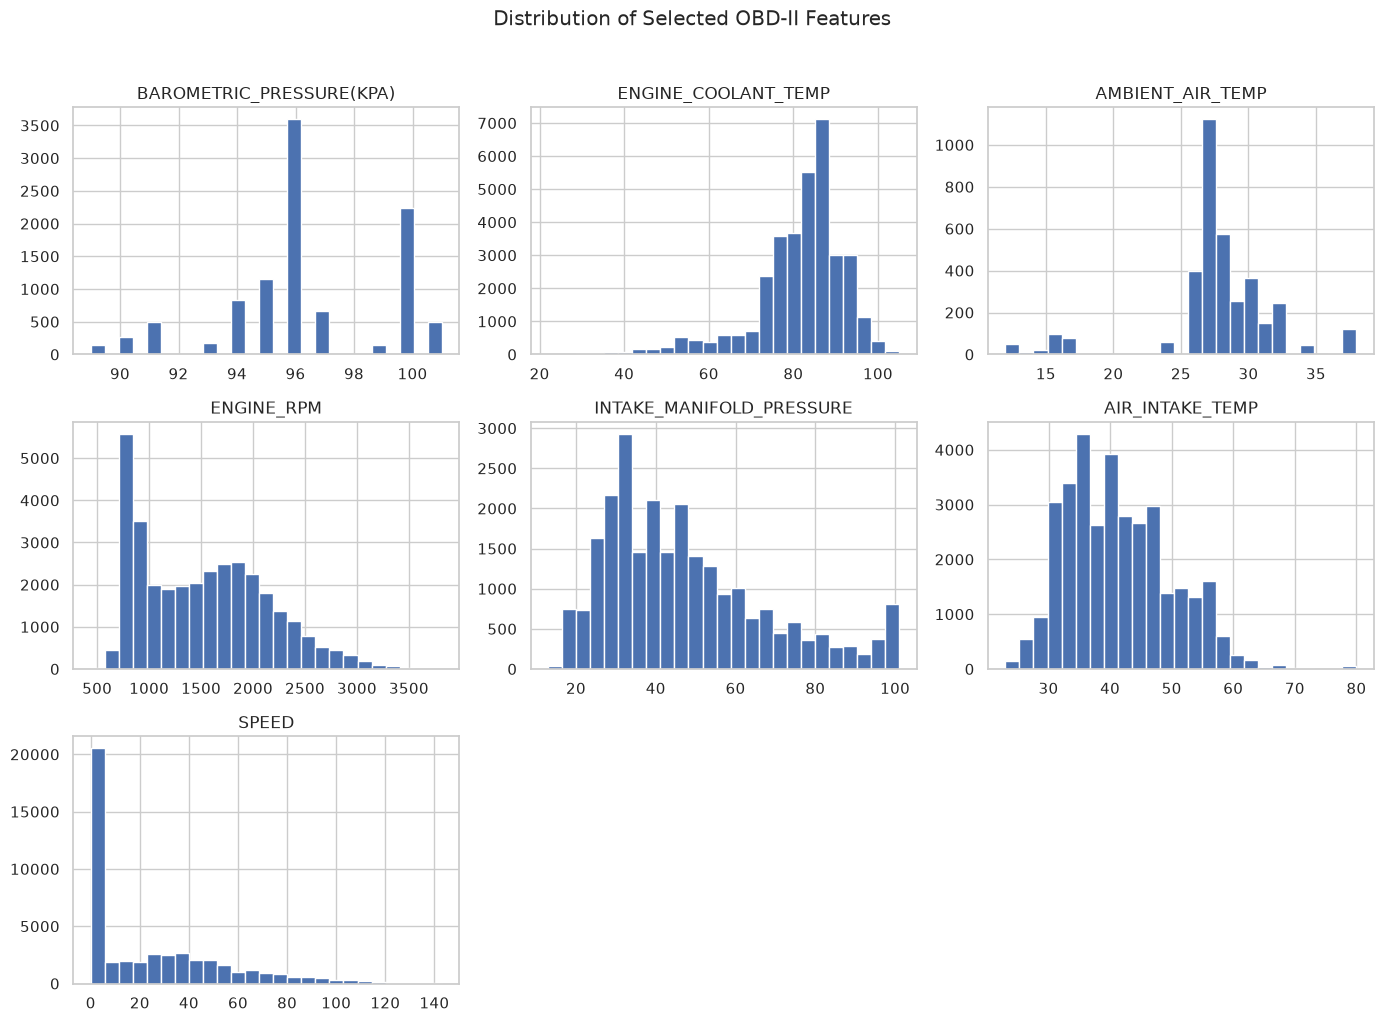

In [7]:
cars.hist(figsize=(14, 10), bins=25)
plt.suptitle("Distribution of Selected OBD-II Features", y=1.02)
plt.tight_layout()
plt.show()

### Distribution observations

- The selected measurements have different distribution shapes and different numerical scales.
- `SPEED` contains many low values because vehicles may be stopped or moving slowly during data collection.
- `ENGINE_RPM` is concentrated around common operating ranges, with some higher values.
- Temperature and pressure measurements are concentrated within narrower ranges than RPM and speed.
- Missing values are ignored automatically by the plotting functions.

## Box plots

Box plots help visualize the median, quartiles, spread, and potential outliers.

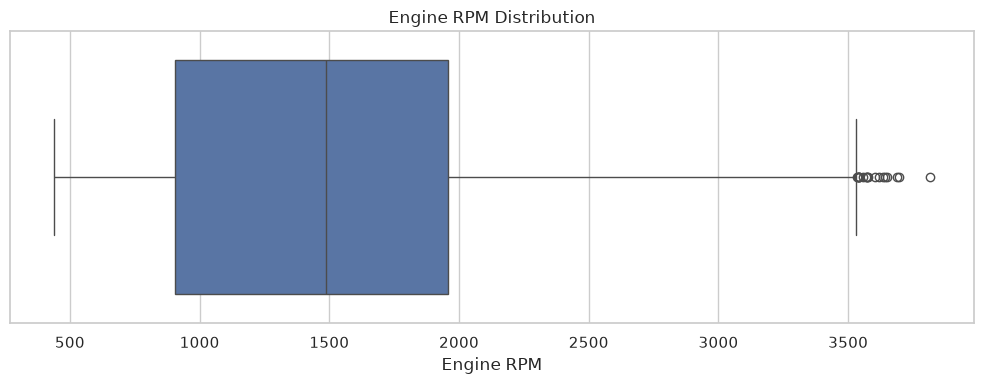

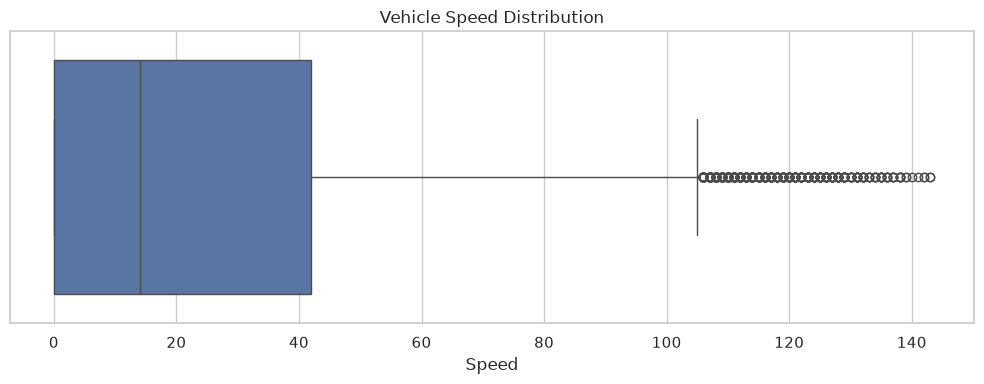

In [8]:
plt.figure(figsize=(10, 4))
sns.boxplot(data=cars, x="ENGINE_RPM")
plt.title("Engine RPM Distribution")
plt.xlabel("Engine RPM")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 4))
sns.boxplot(data=cars, x="SPEED")
plt.title("Vehicle Speed Distribution")
plt.xlabel("Speed")
plt.tight_layout()
plt.show()

## IQR outlier detection for Engine RPM

Use the IQR method to identify potential RPM outliers. These values are investigated rather than automatically removed.

In [9]:
rpm = cars["ENGINE_RPM"].dropna()

rpm_q1 = rpm.quantile(0.25)
rpm_q3 = rpm.quantile(0.75)
rpm_iqr = rpm_q3 - rpm_q1

rpm_lower = rpm_q1 - 1.5 * rpm_iqr
rpm_upper = rpm_q3 + 1.5 * rpm_iqr

rpm_outliers = rpm[
    (rpm < rpm_lower) |
    (rpm > rpm_upper)
]

rpm_outlier_percentage = len(rpm_outliers) / len(rpm) * 100

print("Q1:", round(rpm_q1, 2))
print("Q3:", round(rpm_q3, 2))
print("IQR:", round(rpm_iqr, 2))
print("Lower bound:", round(rpm_lower, 2))
print("Upper bound:", round(rpm_upper, 2))
print("Number of RPM outliers:", len(rpm_outliers))
print("Outlier percentage:", round(rpm_outlier_percentage, 2), "%")

Q1: 906.0
Q3: 1957.0
IQR: 1051.0
Lower bound: -670.5
Upper bound: 3533.5
Number of RPM outliers: 19
Outlier percentage: 0.06 %


### Decision on RPM outliers

The detected values are kept in the dataset. High RPM readings may represent real acceleration or high-engine-load situations, so values outside the IQR bounds are potential outliers rather than confirmed errors.

## Bivariate analysis — Engine RPM and Speed

Examine the relationship between engine speed and vehicle speed.

RPM and speed correlation: 0.84


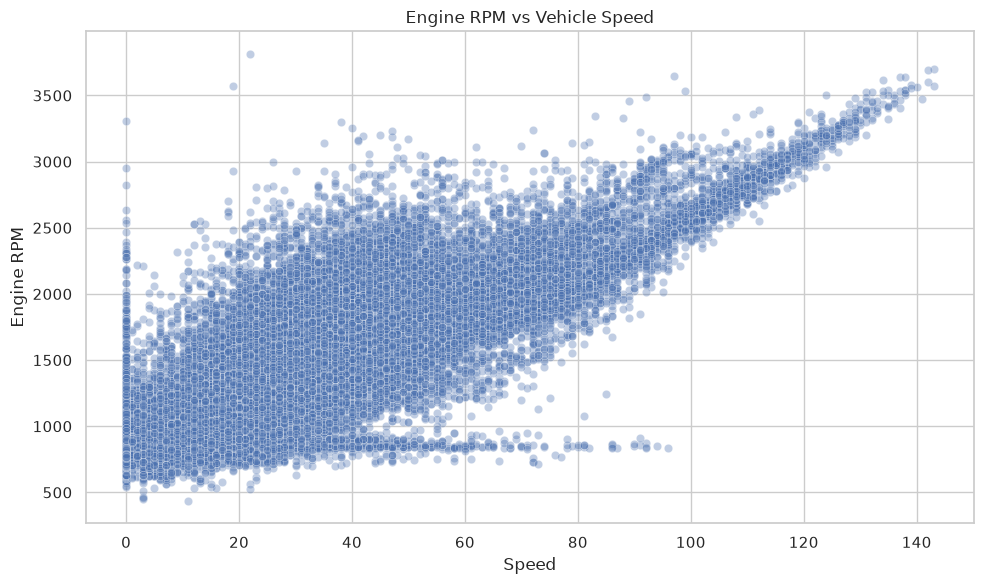

In [10]:
rpm_speed = df[["ENGINE_RPM", "SPEED"]].dropna()

rpm_speed_correlation = rpm_speed.corr().loc["ENGINE_RPM", "SPEED"]
print("RPM and speed correlation:", round(rpm_speed_correlation, 2))

plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=rpm_speed,
    x="SPEED",
    y="ENGINE_RPM",
    alpha=0.35
)

plt.title("Engine RPM vs Vehicle Speed")
plt.xlabel("Speed")
plt.ylabel("Engine RPM")
plt.tight_layout()
plt.show()

### RPM and speed result

The scatter plot and the correlation value show a clear positive relationship. Vehicle speed generally increases as engine RPM increases, although the relationship is not perfect because gear selection, traffic conditions, and driving behavior also affect both measurements.

## Speed distribution by car model

Compare speed values across the most frequently recorded vehicle models.

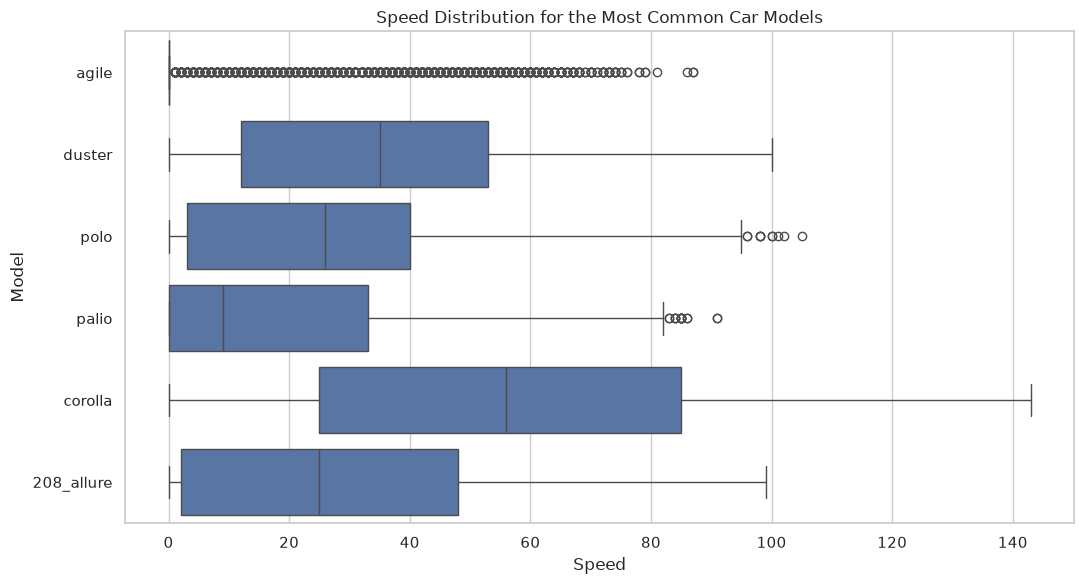

In [11]:
top_models = df["MODEL"].value_counts().head(6).index
model_speed = df[df["MODEL"].isin(top_models)][["MODEL", "SPEED"]].dropna()

plt.figure(figsize=(11, 6))
sns.boxplot(
    data=model_speed,
    x="SPEED",
    y="MODEL"
)

plt.title("Speed Distribution for the Most Common Car Models")
plt.xlabel("Speed")
plt.ylabel("Model")
plt.tight_layout()
plt.show()

### Model comparison result

The grouped box plot shows that speed distributions differ between vehicle models. These differences may be related to the recorded routes, driving conditions, vehicle characteristics, or the amount of data collected for each model.

## Correlation matrix

Calculate the linear relationships between the selected numeric vehicle measurements.

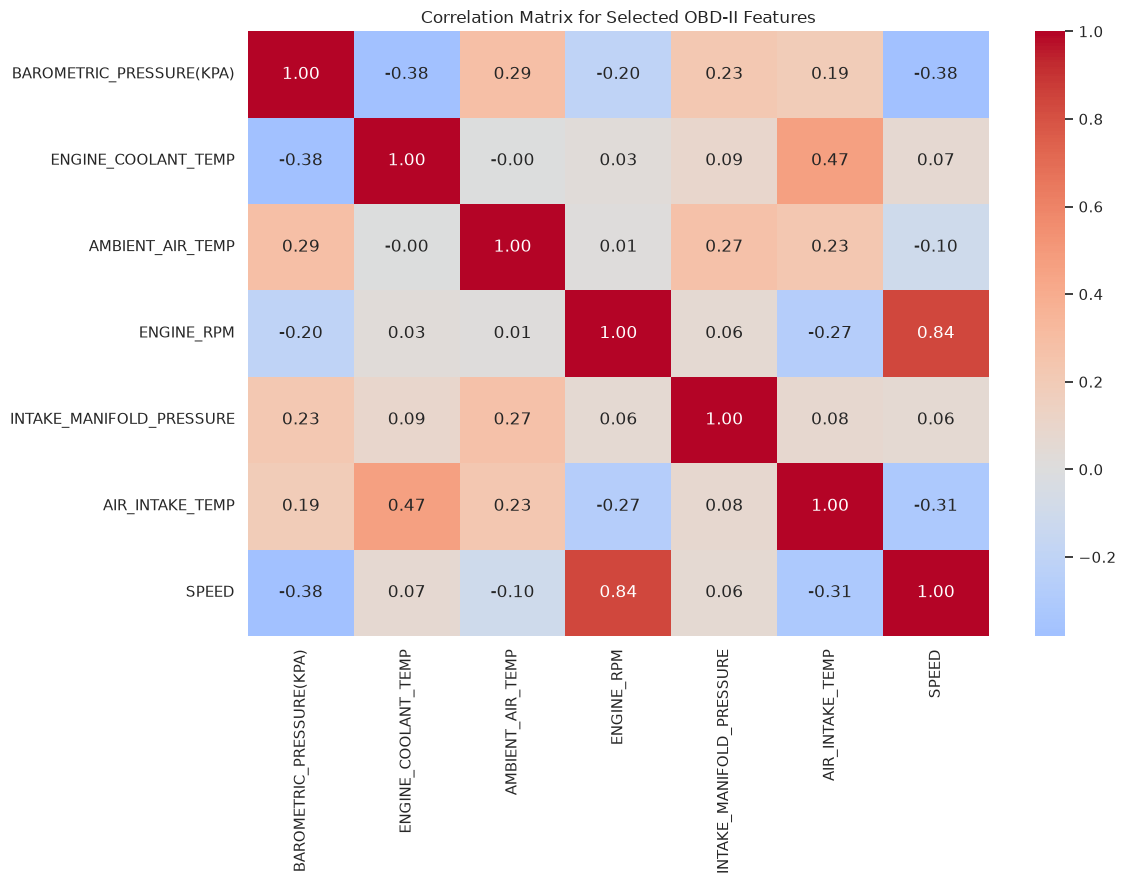

In [12]:
correlation_df = cars.dropna(how="all")
corr = correlation_df.corr()

plt.figure(figsize=(12, 9))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Matrix for Selected OBD-II Features")
plt.tight_layout()
plt.show()

## Strongest correlation relationships

Extract the strongest unique relationships instead of relying only on visual inspection of the heatmap.

In [13]:
upper_triangle = corr.where(
    np.triu(
        np.ones(corr.shape),
        k=1
    ).astype(bool)
)

strongest_pairs = (
    upper_triangle
    .stack()
    .sort_values(
        key=lambda values: values.abs(),
        ascending=False
    )
)

print("Strongest correlation pairs:")
for (first_feature, second_feature), value in strongest_pairs.head(5).items():
    print(f"{first_feature} and {second_feature}: {value:.2f}")

Strongest correlation pairs:
ENGINE_RPM and SPEED: 0.84
ENGINE_COOLANT_TEMP and AIR_INTAKE_TEMP: 0.47
BAROMETRIC_PRESSURE(KPA) and ENGINE_COOLANT_TEMP: -0.38
BAROMETRIC_PRESSURE(KPA) and SPEED: -0.38
AIR_INTAKE_TEMP and SPEED: -0.31


### Correlation findings

- The strongest relationships are printed above with their actual correlation values.
- A positive value means that two measurements tend to increase together.
- A negative value means that one measurement tends to decrease as the other increases.
- A high correlation can indicate useful information, but it can also show that two features contain overlapping information.
- Correlation describes association and does not prove causation.

## Pairplot

Use a sample of the complete records to scan several important sensor relationships without making the plot unnecessarily slow.

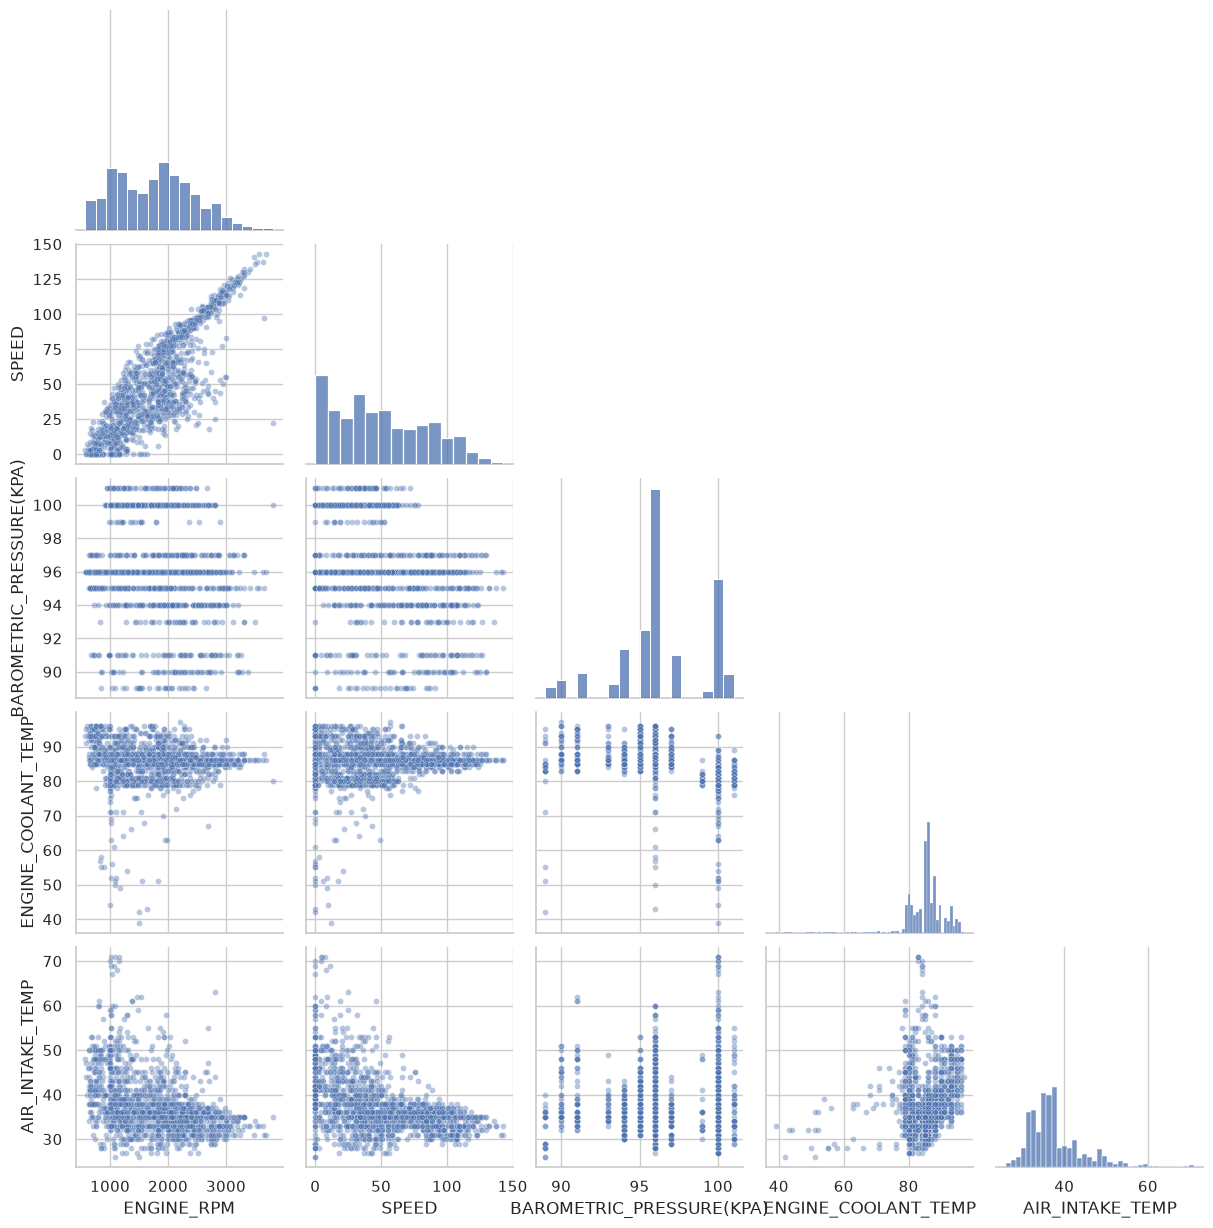

In [14]:
pairplot_columns = [
    "ENGINE_RPM",
    "SPEED",
    "BAROMETRIC_PRESSURE(KPA)",
    "ENGINE_COOLANT_TEMP",
    "AIR_INTAKE_TEMP"
]

pairplot_columns = [
    column for column in pairplot_columns
    if column in df.columns
]

pairplot_df = df[pairplot_columns].dropna()

if len(pairplot_df) > 1500:
    pairplot_df = pairplot_df.sample(1500, random_state=40)

sns.pairplot(
    pairplot_df,
    corner=True,
    diag_kind="hist",
    plot_kws={"alpha": 0.4, "s": 18}
)

plt.show()

### Pairplot result

The pairplot provides a quick comparison of the selected vehicle measurements. It confirms the relationship between RPM and speed, shows the individual distributions on the diagonal, and helps identify clusters, nonlinear patterns, and unusual observations.

## Data storytelling summary

The dataset contains OBD-II readings collected from several vehicles and includes vehicle information, engine measurements, temperature values, pressure values, RPM, and speed.

The data-quality inspection showed that missing values are a major characteristic of this dataset because different vehicles do not report all sensor signals. For this reason, the analysis uses available observations for each selected feature instead of deleting every row that contains a missing value.

The descriptive statistics and distributions show that the vehicle measurements have different centers, spreads, and scales. The IQR method identifies potential high-RPM observations, but these readings are kept because they may describe real driving situations.

The bivariate analysis shows a clear positive relationship between engine RPM and vehicle speed. The model comparison also shows that the recorded speed distributions are not identical across all vehicles.

The correlation matrix and pairplot highlight the most important relationships between the selected sensor measurements. These findings can guide feature selection, but correlation alone cannot explain the cause of a relationship.

## Modeling considerations

- Missing sensor values must be handled before training a machine learning model.
- Features with very different scales may require normalization or standardization.
- Highly correlated features should be reviewed because they may contain repeated information.
- Potential outliers should be investigated before deciding to remove them.
- Vehicle model and vehicle ID may affect the sensor patterns and should be considered when evaluating a future model.
- The final model should combine several sensor measurements rather than depend on one feature only.

## Final conclusion

This notebook completed a full exploratory analysis of the OBD-II vehicle dataset. It combined data cleaning, descriptive statistics, distribution analysis, IQR outlier detection, bivariate visualization, correlation analysis, pairplot scanning, and written interpretation.

The dataset contains useful relationships for future machine learning work, especially between engine RPM and vehicle speed. However, missing values, differences between vehicles, potential outliers, and overlapping feature information must be considered before modeling.